# Plot dot count per cell. Compare untreated vs treated widefield and confocal

In [ ]:
import numpy as np
import pandas as pd
import time
import os
import sys
from tqdm import tqdm, trange
from datetime import date
import nd2reader
from joblib import Parallel, delayed
import tifffile as tf
import xml.etree.ElementTree as ET
import napari
import skimage
from skimage.io import imread
from skimage.measure import block_reduce
from skimage.filters import try_all_threshold
import dask.array as da
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
# from dask_ml.preprocessing import MinMaxScaler
import dask
import matplotlib
import matplotlib.pyplot as plt
import nd2
from skimage import exposure, restoration
from joblib import Parallel, delayed
import torch
from cellpose import models, core, plot
import cv2
import scipy
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from skimage.morphology import closing, square
from skimage.measure import label
import scanpy as sc
import anndata
from anndata import AnnData
import asyncio
from pathlib import Path
from statannot import add_stat_annotation
import itertools

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi = 300)

sns.set(font_scale = 2)
sns.set_style('whitegrid')
np.random.seed(0)

# directories and inputs

In [ ]:
# folder of individual pair cell dataframes
singlePairPath = Path(r"..\data\HCC827 P7 plate 002\19Jan2024 plate 002 cycle 1 PLA 5 pairs\04 PKL single cell")
assert singlePairPath.exists()
dfSingleInfo = pd.read_excel(r"..\data\HCC827 P7 plate 002\19Jan2024 plate 002 cycle 1 PLA 5 pairs\25Jan2024_wells_info.xlsx")

# folder of combo pair cell dataframes
comboPairPath = Path(r"..\data\HCC827 P7 plate 002\24Jan2024 cycle 1 Keyence\05 PKL single cell")
assert comboPairPath.exists()

# folder of confocal combo cell dataframes
confocalComboPath = Path(r"..\data\HCC827 P7 plate 002\23Jan2024 cycle 1 5 pairs Airyscan re image\02 PKL single cell")
assert confocalComboPath.exists()
dfComboInfo = pd.read_excel(r"..\data\HCC827 P7 plate 002\23Jan2024 cycle 1 5 pairs Airyscan re image\25Jan2024_wells_info.xlsx")

# folder to save plots
screenshotSavePath = Path(r"..\figures")
assert screenshotSavePath.exists()

# Delay execution if necessary

In [3]:
# time.sleep(1 * 60 * 60) # sec

# Reformat and compute single cell widefield

In [4]:
# reformat each FOV dataframe to single cell and concat
def reformatDfSingleCell(path, dfInfo): 
    
    df = pd.read_pickle(path)
    # check if empty
    if df.size == 0:
        return None
    
    if 'Untreated' in path.stem:
        treatment = 'Untreated'

    elif 'Treated' in path.stem:
        treatment = 'Treated'

    else: # look up treatment from dfSingleInfo
        well = path.stem
        treatment = dfInfo[dfInfo['WellLabel'] == well]
        assert len(treatment) == 1
        treatment = treatment['Drug'].values[0]

    
    # compute single cell aggregates
    idCols = ['Y', 'X', 'Z', 'FOV', 'MaskCytoLabel', 'MaskNucLabel', 'CellLabel', 'Cycle', 'CellRegion']
    markers = df.drop(columns = idCols).columns
    aggForm = {}
    for ii, markerName in enumerate(markers):
        aggForm[markerName] = 'sum'

    dfCell = df.groupby(['FOV', 'CellLabel']).agg(aggForm).reset_index(drop = False)
    dfCell['Treatment'] = treatment
    
    return dfCell

# read untreated cells
dfFiles = [f for f in singlePairPath.glob('*.pkl')]
# read in parallel
dfAll = Parallel(n_jobs = 2, prefer = 'threads', verbose = 10)\
(delayed(reformatDfSingleCell)(path = fileName, dfInfo = dfSingleInfo) 
 for _, fileName in enumerate(dfFiles))
    
dfSingle = pd.concat(dfAll)
dfSingle.reset_index(drop = True, inplace = True)
dfSingle

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   17.8s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  1.1min
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:  2.4min finished


,FOV,CellLabel,DAPI,Phalloidin,FGFR1_PIK3R1,Treatment,CDK4_CDKN1B,AKT1_SRC,CDC42_CASP3,STK11_PRKAA2
0,1,2,705.022053,306.984340,6.0,Untreated,NaN,NaN,NaN,NaN
1,1,4,2108.268117,1717.590840,9.0,Untreated,NaN,NaN,NaN,NaN
2,1,5,1708.286537,1293.350642,8.0,Untreated,NaN,NaN,NaN,NaN
3,1,6,3415.679008,2006.468739,25.0,Untreated,NaN,NaN,NaN,NaN
4,1,7,780.661212,374.547156,2.0,Untreated,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5982,10,13098,1553.295372,172.182947,NaN,Treated,NaN,NaN,NaN,1.0
5983,10,13101,2698.761348,302.679287,NaN,Treated,NaN,NaN,NaN,20.0
5984,10,13102,4264.008246,380.374375,NaN,Treated,NaN,NaN,NaN,17.0
5985,10,13105,1420.513446,195.801201,NaN,Treated,NaN,NaN,NaN,11.0


In [5]:
# read treated cells
dfFiles = [f for f in comboPairPath.glob('*.pkl')]
# read in parallel
dfAll = Parallel(n_jobs = 2, prefer = 'threads', verbose = 10)\
(delayed(reformatDfSingleCell)(path = fileName, dfInfo = dfSingleInfo) 
 for _, fileName in enumerate(dfFiles))
    
dfCombo = pd.concat(dfAll)
dfCombo.reset_index(drop = True, inplace = True)
dfCombo

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  1.8min remaining:    0.0s
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  1.8min finished


,FOV,CellLabel,DAPI,Combo5,Phalloidin,Treatment
0,2,792,2005.335196,56.0,112.232365,Treated
1,2,793,1518.430168,40.0,148.373444,Treated
2,2,799,1413.921788,58.0,257.398340,Treated
3,2,800,1574.938547,62.0,200.439834,Treated
4,2,804,1563.536313,67.0,112.070539,Treated
...,...,...,...,...,...,...
766,1,770,3866.231343,68.0,162.204724,Untreated
767,1,773,3870.395522,61.0,95.551181,Untreated
768,1,775,3465.425373,50.0,95.476378,Untreated
769,1,778,2106.298507,81.0,296.433071,Untreated


In [6]:
# combine untreated and treated
dfAll = pd.concat([dfSingle, dfCombo])
dfAll

,FOV,CellLabel,DAPI,Phalloidin,FGFR1_PIK3R1,Treatment,CDK4_CDKN1B,AKT1_SRC,CDC42_CASP3,STK11_PRKAA2,Combo5
0,1,2,705.022053,306.984340,6.0,Untreated,NaN,NaN,NaN,NaN,NaN
1,1,4,2108.268117,1717.590840,9.0,Untreated,NaN,NaN,NaN,NaN,NaN
2,1,5,1708.286537,1293.350642,8.0,Untreated,NaN,NaN,NaN,NaN,NaN
3,1,6,3415.679008,2006.468739,25.0,Untreated,NaN,NaN,NaN,NaN,NaN
4,1,7,780.661212,374.547156,2.0,Untreated,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
766,1,770,3866.231343,162.204724,NaN,Untreated,NaN,NaN,NaN,NaN,68.0
767,1,773,3870.395522,95.551181,NaN,Untreated,NaN,NaN,NaN,NaN,61.0
768,1,775,3465.425373,95.476378,NaN,Untreated,NaN,NaN,NaN,NaN,50.0
769,1,778,2106.298507,296.433071,NaN,Untreated,NaN,NaN,NaN,NaN,81.0


# Boxplot dot counts per cell widefield

In [7]:
def saveFigLabelTime(fig): # save figure with current time as label
    now = datetime.now()
    now = now.strftime('%d%b%Y_%H%M%S')
    fileOut = now + '.png'
    fileOut = Path(screenshotSavePath, fileOut)
    fig.savefig(fileOut, dpi = 'figure', bbox_inches = 'tight', pad_inches = 0)

    # wait so figures do not overwrite each other
    time.sleep(2)
    
    return None

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CDK4_CDKN1B_Untreated v.s. CDK4_CDKN1B_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.306e-07 U_stat=2.794e+05
FGFR1_PIK3R1_Untreated v.s. FGFR1_PIK3R1_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.415e-33 U_stat=1.969e+04
AKT1_SRC_Untreated v.s. AKT1_SRC_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=7.363e-06 U_stat=1.139e+05
CDC42_CASP3_Untreated v.s. CDC42_CASP3_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.199e-06 U_stat=1.391e+05
STK11_PRKAA2_Untreated v.s. STK11_PRKAA2_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.901e-10 U_stat=3.177e+05
Combo5_Untreated v.s. Combo5_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val

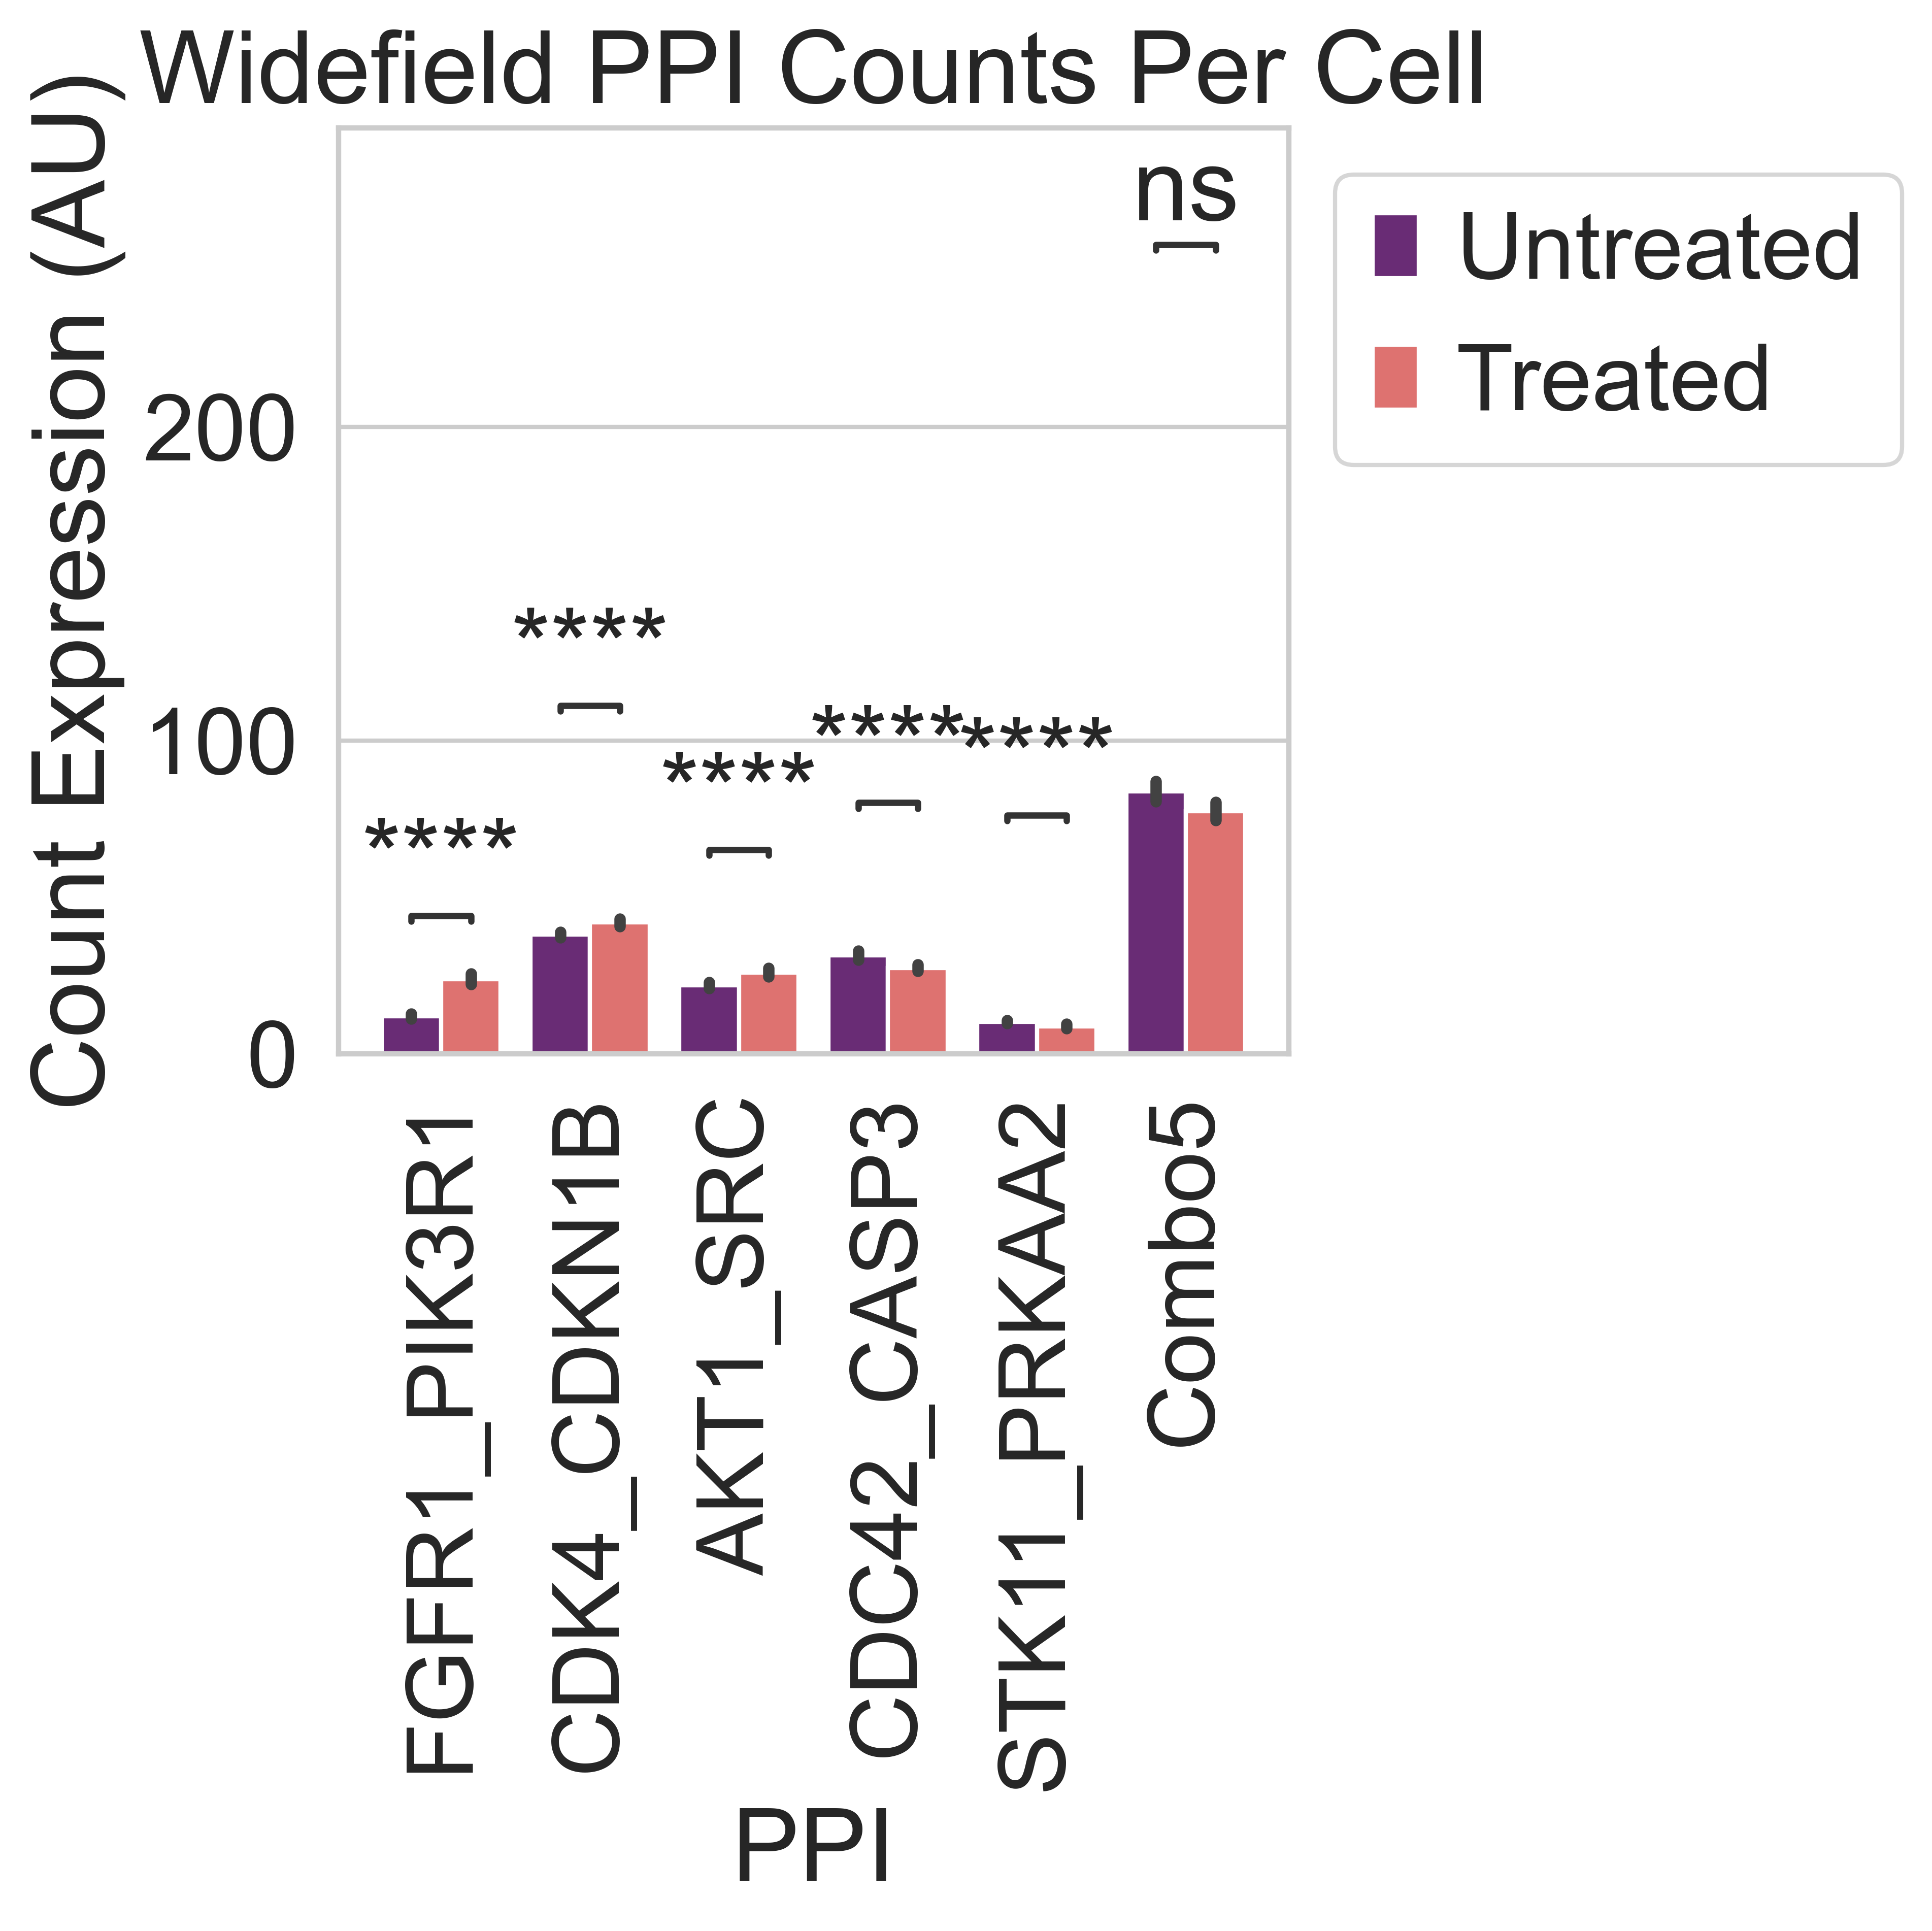

In [8]:
# boxplot
dotCols = [col for col in dfAll.columns if '_' in col or 'Combo' in col]
# reformat
widefield = dfAll.melt(id_vars = ['FOV', 'CellLabel', 'Treatment'], value_vars = dotCols, var_name = 'PPI', value_name = 'DotCount')

x = 'PPI'
y = 'DotCount'
hue = 'Treatment'

fig, ax = plt.subplots(dpi = 300)
sns.barplot(data = widefield, x = x, y = y, hue = hue, ax = ax, palette = 'magma')
ax.set_ylabel('Count Expression (AU)')
ax.set_title('Widefield PPI Counts Per Cell')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.legend(title = '', bbox_to_anchor = (1, 1), loc = 'upper left')

# add stat test
pairLabels = [f.get_text() for f in ax.get_xticklabels()]
boxPairs = [((p, 'Untreated'), (p, 'Treated')) for p in pairLabels]

add_stat_annotation(ax = ax, data = widefield, x = x, y = y, hue = hue, 
                    loc = 'inside', test = 'Mann-Whitney', verbose = 2, box_pairs=boxPairs, 
                    line_offset_to_box= -0.5)

saveFigLabelTime(fig)

# Plot single cell counts for confocal

In [9]:
# reformat each FOV dataframe to single cell and concat
def reformatDfSingleCell(path, dfInfo): 
    
    df = pd.read_pickle(path)
    # check if empty
    if df.size == 0:
        return None
   
    # look up treatment from dfSingleInfo
    well = path.stem
    for row1 in dfInfo.itertuples():

        if row1.WellLabel in well:
            treatment = row1.Drug
            break

    # treatment = dfInfo.loc[dfInfo['WellLabel'].isin([well])]
    # print(treatment)
    # assert len(treatment) == 1
    # treatment = treatment['Drug'].values[0]

    # # positive PLA counts
    # df = df.loc[df['Combo'] > 0]
    
    # compute single cell aggregates
    idCols = ['Y', 'X', 'Z', 'MaskCytoLabel', 'MaskNucLabel', 'Cycle', 'CellRegion']
    # markers = df.drop(columns = idCols).columns
    # aggForm = {}
    # for ii, markerName in enumerate(markers):
    #     aggForm[markerName] = 'sum'
    df.drop(columns = idCols, inplace = True, errors='ignore')
    dfCell = df.groupby(['FOV', 'CellLabel']).sum(numeric_only = True).reset_index(drop = False)

    # dfCell = df.groupby(['FOV', 'CellLabel']).agg(aggForm).reset_index(drop = False)
    dfCell['Treatment'] = treatment
    
    return dfCell

# read untreated cells
dfFiles = [f for f in confocalComboPath.glob('*.pkl')]
# read in parallel
dfAll = Parallel(n_jobs = 2, prefer = 'threads', verbose = 10)\
(delayed(reformatDfSingleCell)(path = fileName, dfInfo = dfComboInfo) 
 for _, fileName in enumerate(dfFiles))
    
dfConfocal = pd.concat(dfAll)
dfConfocal.reset_index(drop = True, inplace = True)
dfConfocal

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    4.6s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    9.7s
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:   19.5s
[Parallel(n_jobs=2)]: Done  13 out of  13 | elapsed:   32.5s finished


,FOV,CellLabel,Combo,Phalloidin,DAPI,Treatment
0,1,3,420.0,53589.235860,7.690762e+03,Untreated
1,1,10,1536.0,66246.141998,1.014690e+06,Untreated
2,1,13,1233.0,96860.930205,2.834835e+05,Untreated
3,1,28,914.0,32449.238267,7.287225e+05,Untreated
4,1,30,2485.0,142025.215403,1.040473e+06,Untreated
5,1,42,3214.0,283510.631769,1.057119e+06,Untreated
6,1,48,354.0,49320.432010,5.974377e+04,Untreated
7,1,51,466.0,34022.316486,1.904825e+05,Untreated
8,2,52,703.0,15796.402542,1.919778e+05,Untreated
9,2,57,695.0,28477.718927,2.794173e+05,Untreated


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Untreated v.s. Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.412e-01 U_stat=2.055e+02


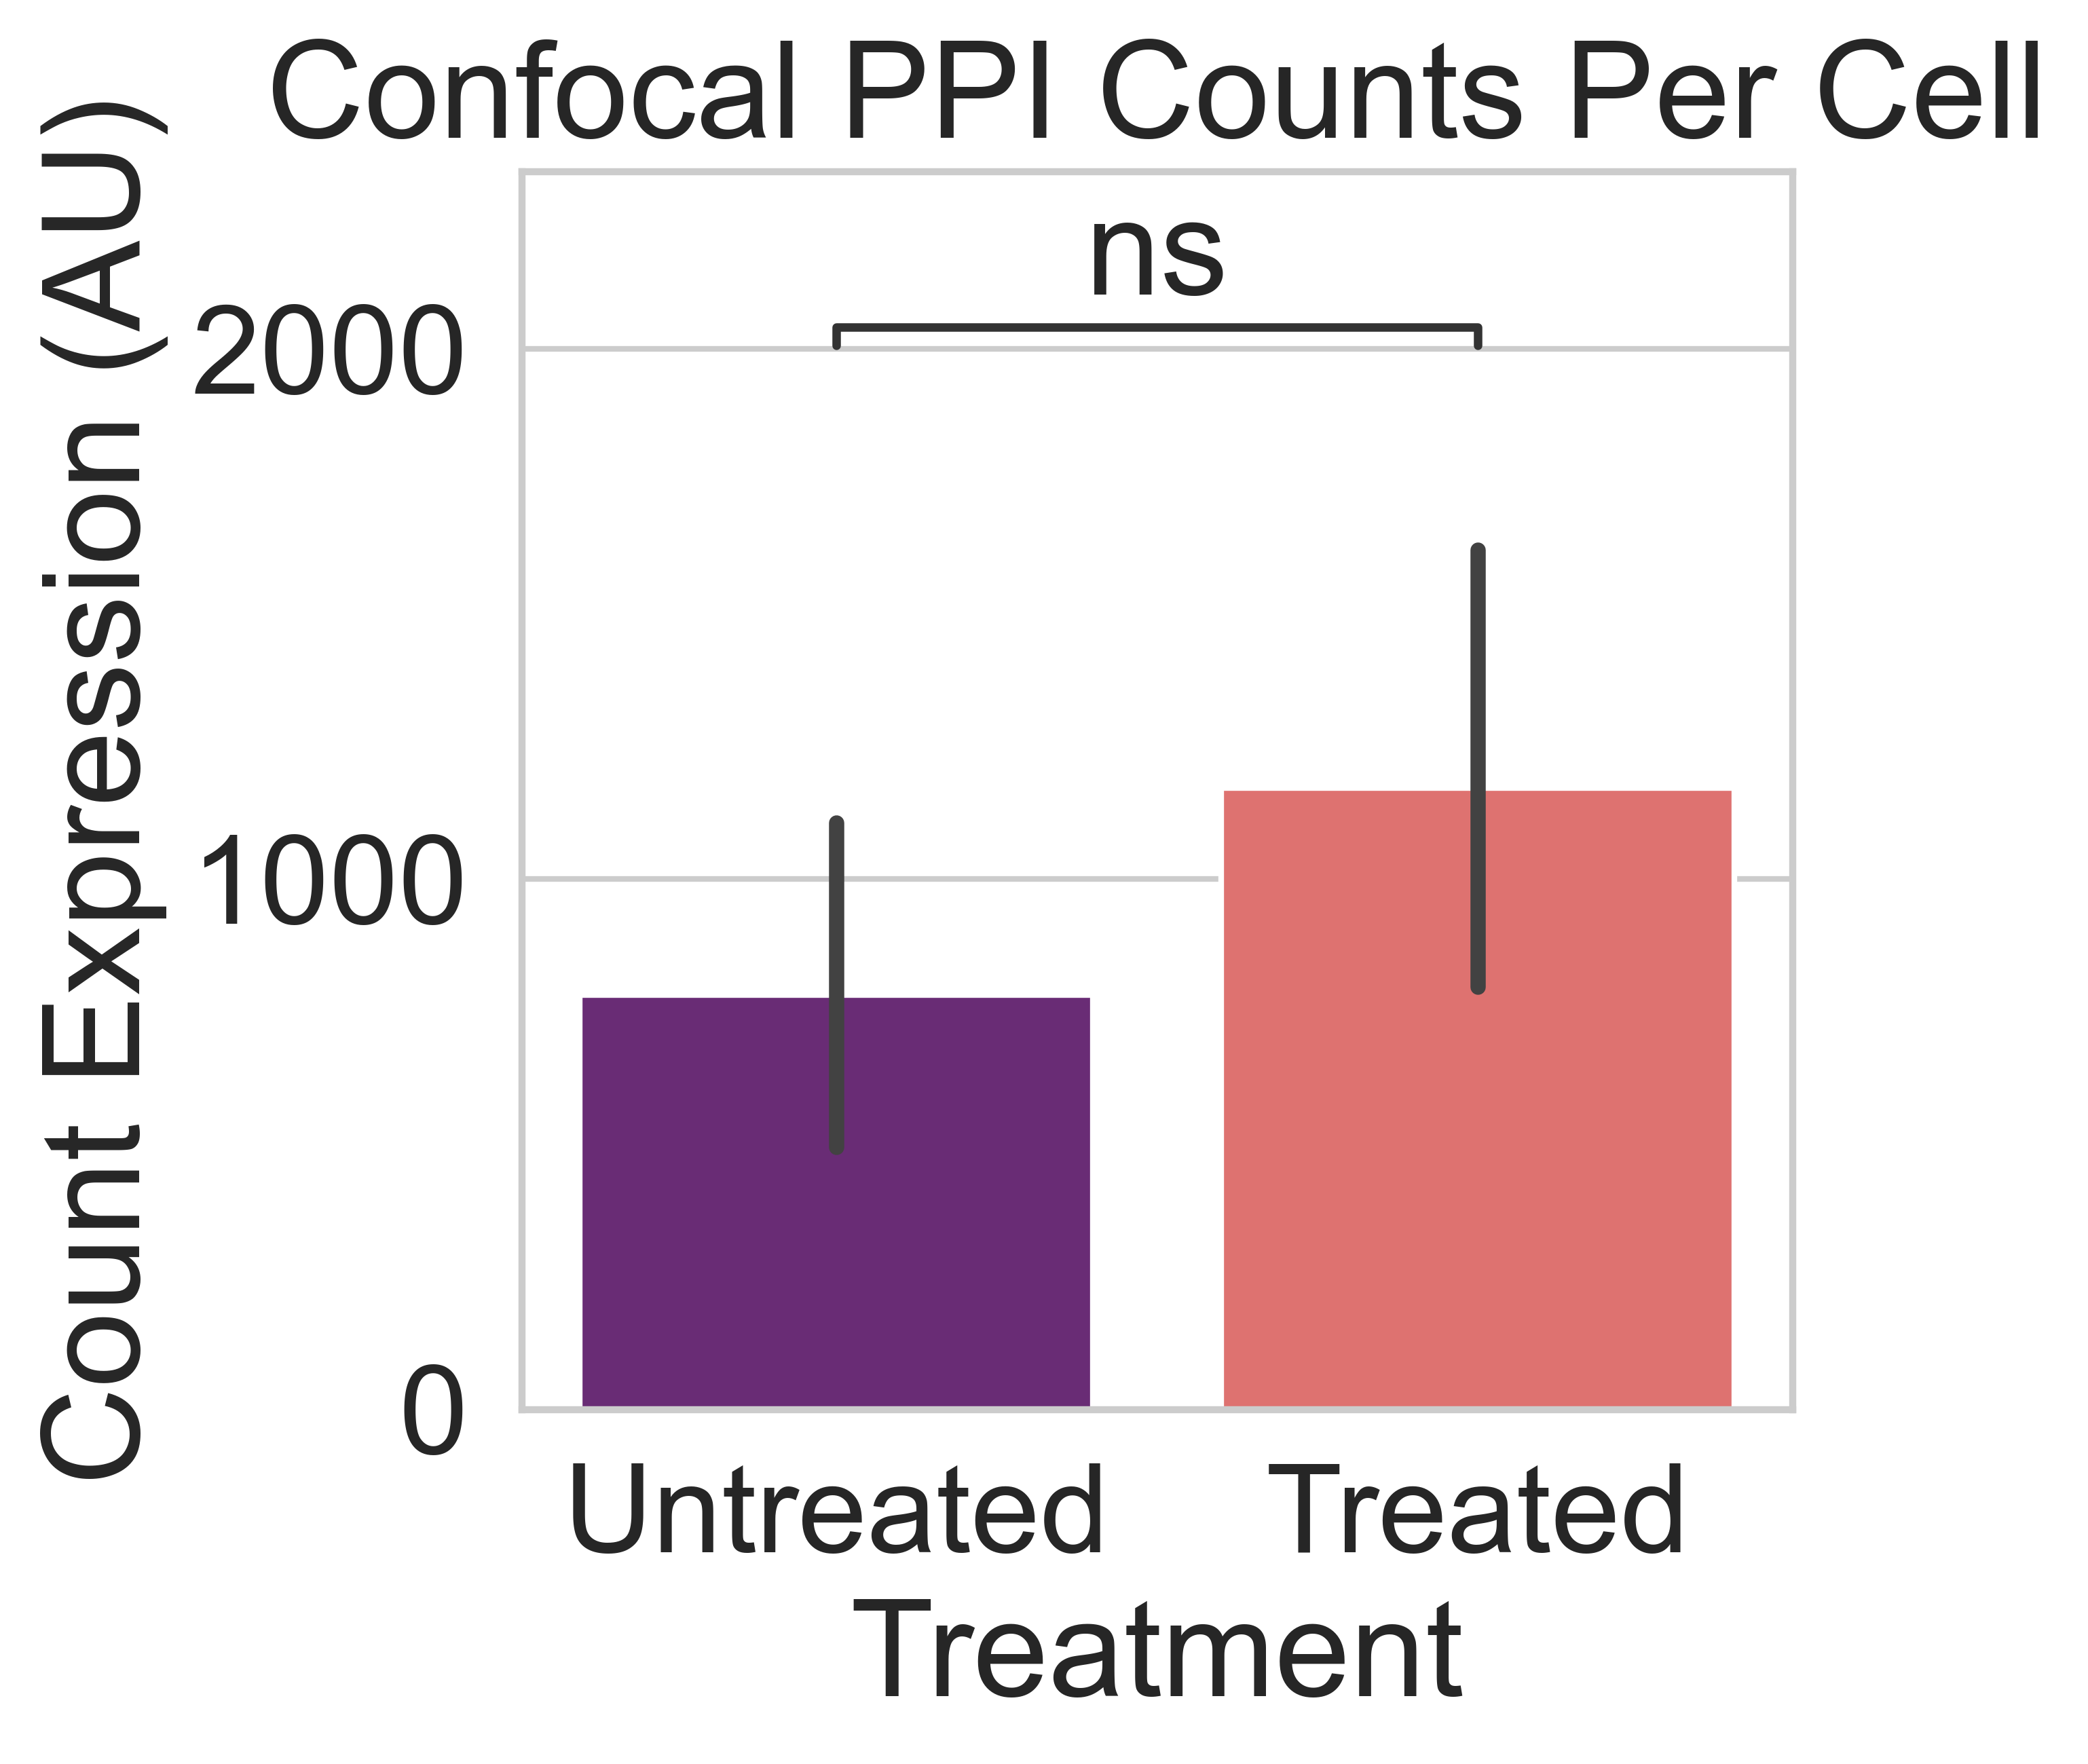

In [10]:
# boxplot
dotCols = [col for col in dfConfocal.columns if '_' in col or 'Combo' in col]
# reformat
confocal = dfConfocal.melt(id_vars = ['FOV', 'CellLabel', 'Treatment'], \
                           value_vars = dotCols, var_name = 'PPI', value_name = 'DotCount')

x = 'Treatment'
y = 'DotCount'

fig, ax = plt.subplots(dpi = 300)
sns.barplot(data = confocal, x = x, y = y, ax = ax, palette = 'magma')
ax.set_ylabel('Count Expression (AU)')
ax.set_title('Confocal PPI Counts Per Cell')
# ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
# ax.legend(title = '', bbox_to_anchor = (1, 1), loc = 'upper left')

# add stat test
# pairLabels = confocal['Treatment'].unique()
# boxPairs = [((p, 'Untreated'), (p, 'Treated')) for p in pairLabels]
boxPairs = [dfConfocal['Treatment'].unique().tolist()]

add_stat_annotation(ax = ax, data = confocal, x = x, y = y, 
                    loc = 'inside', test = 'Mann-Whitney', verbose = 2, box_pairs=boxPairs,
                    line_offset_to_box=-1.3)

saveFigLabelTime(fig)

# Plot combo confocal and widefield counts

In [11]:
# concat combo confocal and widefield counts
singlePairs = [c for c in widefield.columns if '_' in c]
widefield['Microscope'] = 'Widefield'
confocal['Microscope'] = 'Confocal'
dfCompare = pd.concat([widefield.drop(columns = singlePairs), 
                       confocal])
dfCompare

,FOV,CellLabel,Treatment,PPI,DotCount,Microscope
0,1,2,Untreated,FGFR1_PIK3R1,6.0,Widefield
1,1,4,Untreated,FGFR1_PIK3R1,9.0,Widefield
2,1,5,Untreated,FGFR1_PIK3R1,8.0,Widefield
3,1,6,Untreated,FGFR1_PIK3R1,25.0,Widefield
4,1,7,Untreated,FGFR1_PIK3R1,2.0,Widefield
...,...,...,...,...,...,...
42,8,287,Treated,Combo,97.0,Confocal
43,8,288,Treated,Combo,276.0,Confocal
44,9,289,Treated,Combo,2246.0,Confocal
45,9,291,Treated,Combo,735.0,Confocal


In [12]:
# optional: plot combo pairs only. Drop single pairs
dfCompare = dfCompare.loc[dfCompare['PPI'].str.contains('Combo')]

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Widefield_Untreated v.s. Confocal_Untreated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=6.140e-10 U_stat=9.505e+02
Widefield_Treated v.s. Confocal_Treated: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.169e-15 U_stat=1.360e+02


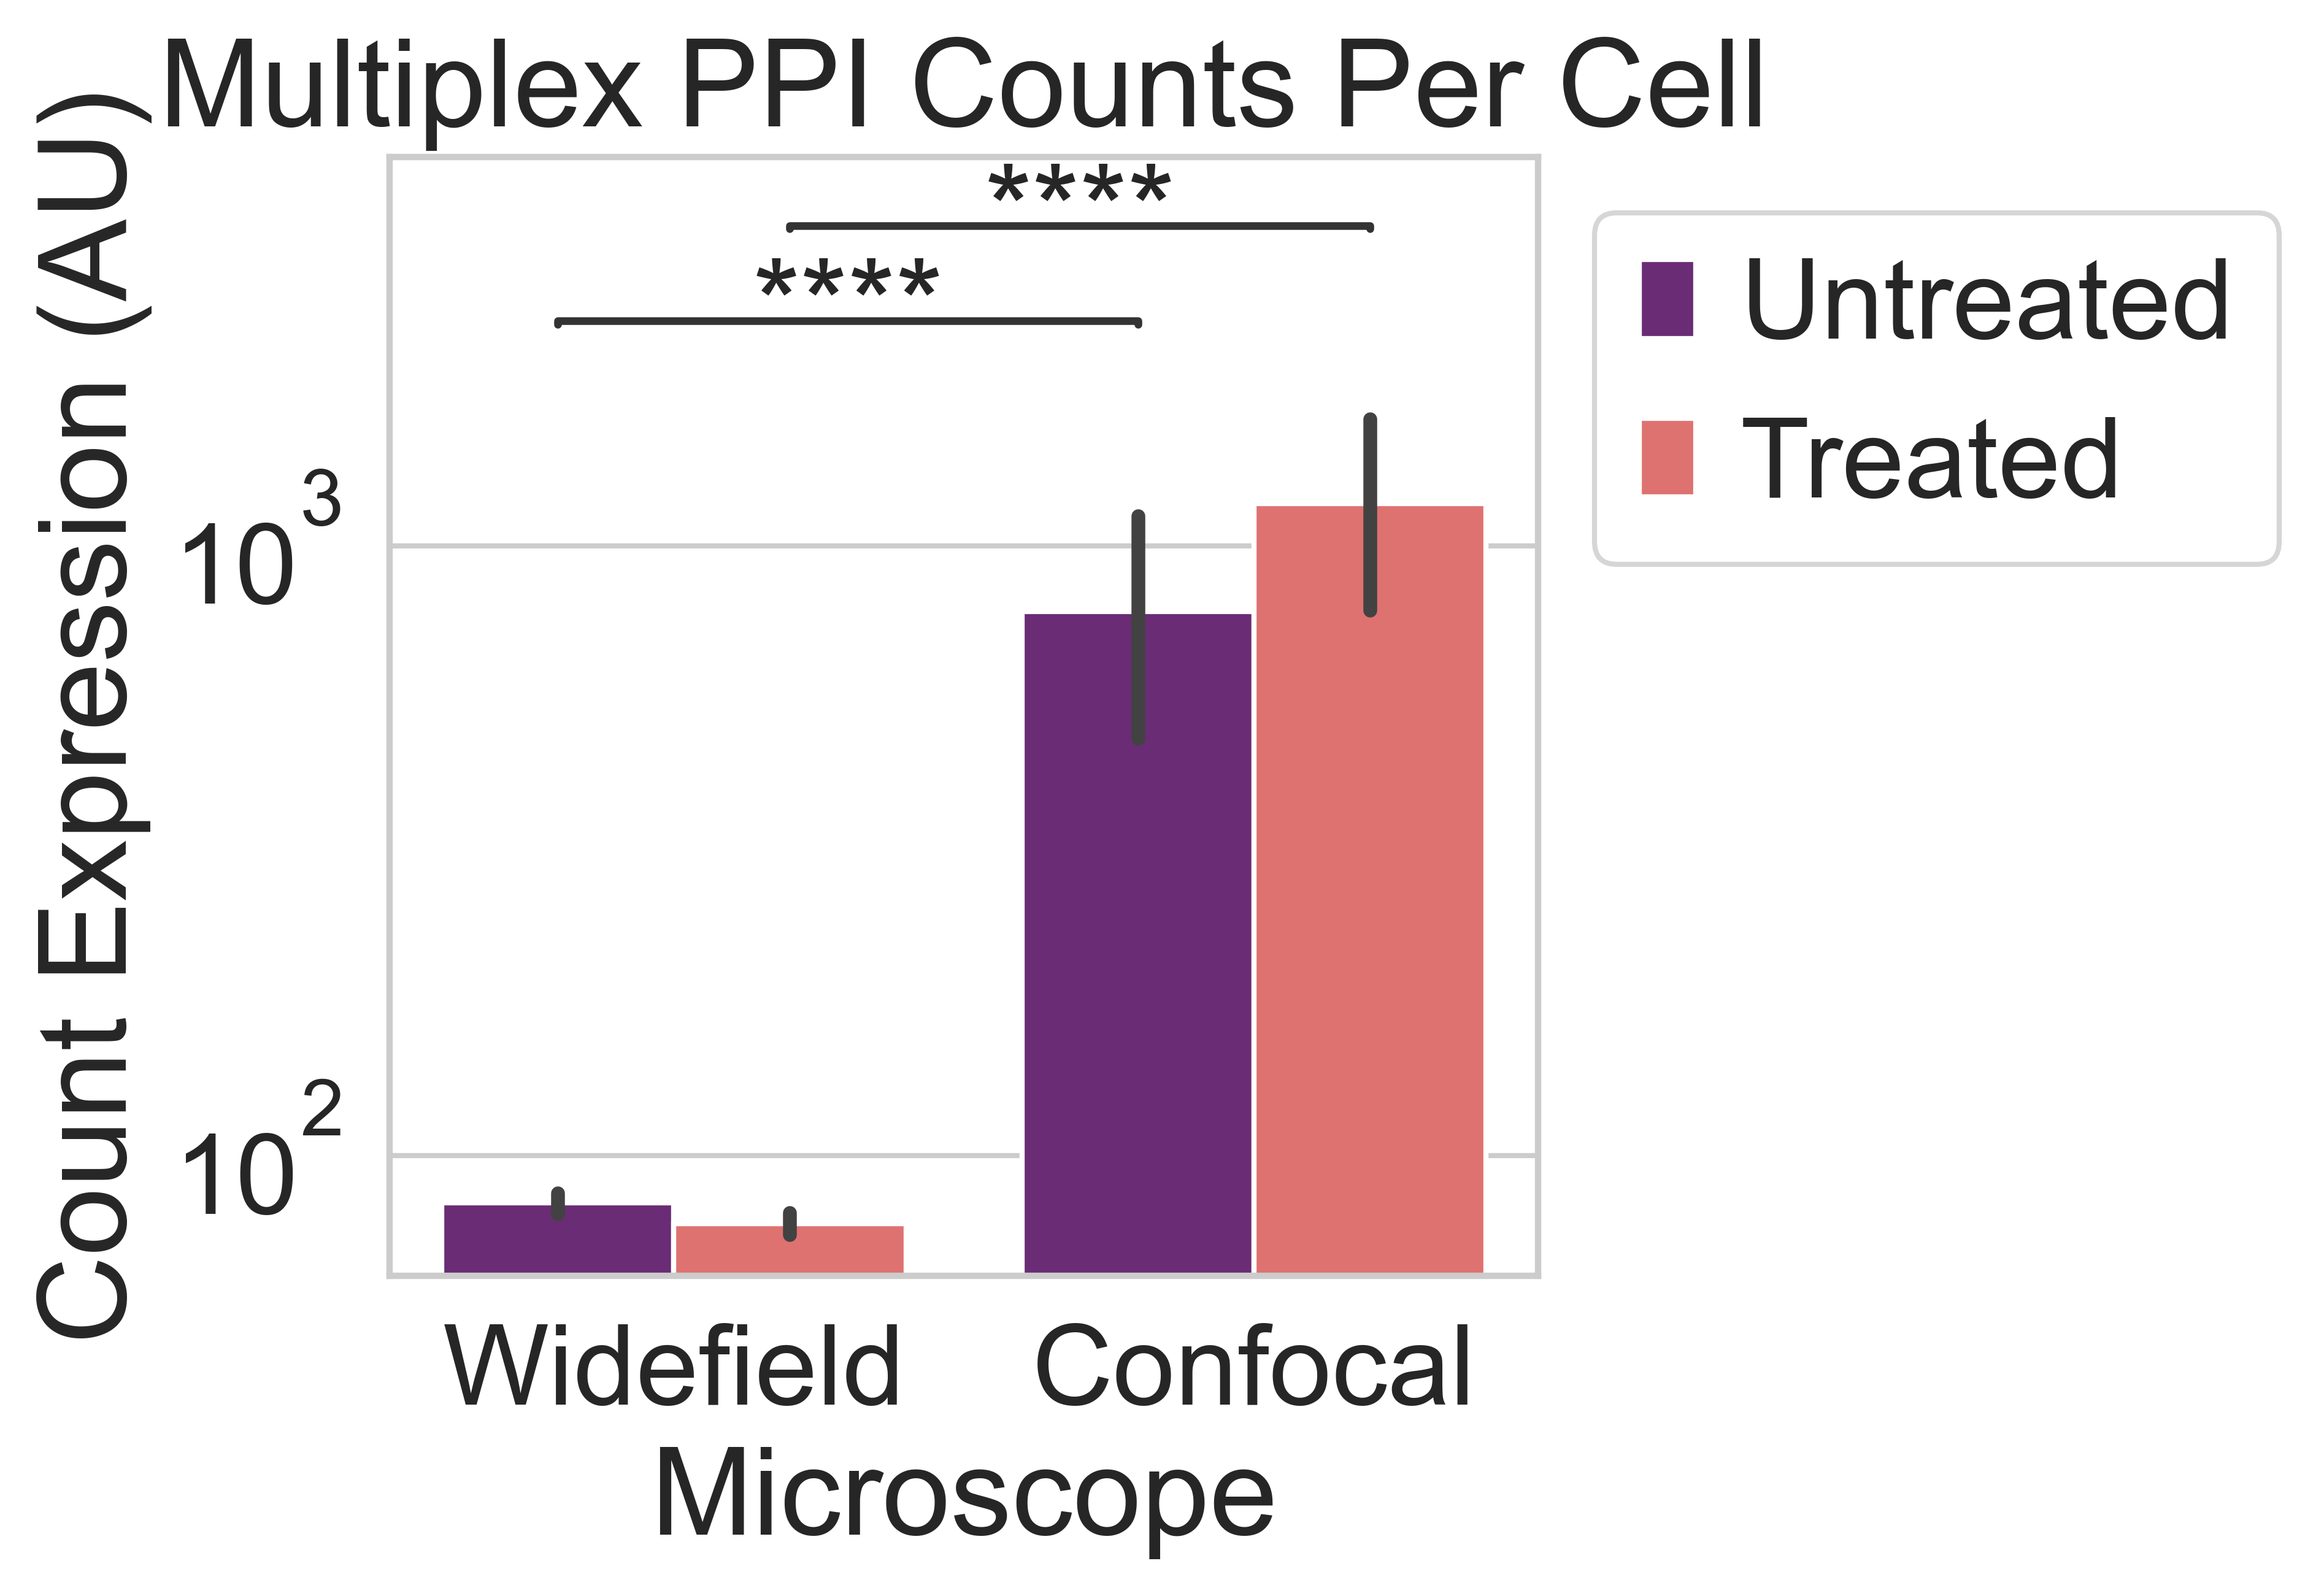

In [13]:
# boxplot
dotCols = [col for col in dfCompare.columns if '_' in col or 'Combo' in col]

x = 'Microscope'
y = 'DotCount'
hue = 'Treatment'

fig, ax = plt.subplots(dpi = 300)
sns.barplot(data = dfCompare, x = x, y = y, hue = hue, ax = ax, palette = 'magma')
ax.set_ylabel('Count Expression (AU)')
ax.set_title('Multiplex PPI Counts Per Cell')
# ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.legend(title = '', bbox_to_anchor = (1, 1), loc = 'upper left')
ax.set_yscale('log')

# add stat test
pairLabels = [f.get_text() for f in ax.get_xticklabels()]
boxPairs = [((pairLabels[0], treat), (pairLabels[1], treat)) for treat in dfCompare['Treatment'].unique()]

add_stat_annotation(ax = ax, data = dfCompare, x = x, y = y, hue = hue, 
                    loc = 'inside', test = 'Mann-Whitney', verbose = 2, box_pairs=boxPairs, 
                    line_offset_to_box= -0.5, text_offset=-10, line_offset=100)

saveFigLabelTime(fig)